## Bayesian Causal Forest for HTE
**Model**: BCF for outcomes (probit link): model baseline μ(X) and treatment effect surface τ(X) with treatment A and include PS p(X) (or logit PS) as a covariate to correct for targeted selection.

BART is modelled with a PROBIT link function
$$Y_i = \mu_{i}(X, \hat{p}) + \tau_i(X) \cdot T_i$$

- $\mu(x_i, \pi_i)$ = the **prognostic function** — captures baseline outcome risk, regardless of treatment. $\pi_i$ are the propensity score estimates.
- $\tau(x_i)$ = the **treatment effect function** — captures how the treatment effect varies with covariates (this is CATE)
- $T \in {0,1}$ is the treatment indicator

In [1]:
import os
import sys
import seaborn as sns
from scipy.stats import norm
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import arviz as az
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from ISYE6420.Project.bcf_vis import build_ite_rd, plot_gates, build_clan_table, print_clan_table, build_ite_rd_inplace
rng = np.random.default_rng(123)

output_folder = "ISYE6420/Project/"

## Data Loading and Preparation

In [2]:
# Import configurations
dx_name = "copd"
version = "v7_040226"
exac_type = "moderate"

cohort = pd.read_csv(f"ISYE6420\\Project\\data\\{dx_name}_{exac_type}_cohort.csv")
print(len(cohort))

114008


In [3]:
y = cohort["outcome"].values
treatment = cohort["exposure"].values
follow_up_time = cohort["follow_up_time"].values
# Convert to binary indicator for outcome
y_data = (y > 0).astype(int)


### 1. Prognostic Model $\mu(X, \hat{p})$

In [4]:
X = cohort.drop(columns=["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"])
# convert True False columns to int
X = X.astype(int)
# Logit transform the propensity scores for better modeling
propensity_score = cohort["ps_score"]
eps = 1e-6
ps_values = np.clip(propensity_score, eps, 1 - eps)
logit_ps = np.log(ps_values / (1 - ps_values))
X['logit_ps'] = logit_ps
X_mu = X.values

prognostic_model_config = {
    "n_trees": 50,
    "beta_prior": 2,
    "alpha_prior": 0.95,
}

In [5]:
num_exac_pats = cohort[cohort['outcome'] > 0]['patid'].nunique()/ cohort['patid'].nunique()
print(f"Proportion of patients with at least one event: {num_exac_pats:.2%}")

Proportion of patients with at least one event: 7.60%


In [6]:
X.columns

Index(['age', 'gold_class', 'moderate_exac_count', 't2dm_present',
       'num_treatments_baseline', 'num_outpatient_event', 'num_er_event',
       'Acute_IHD_flag', 'CAD_flag', 'PVD_flag', 'atopic_disease_flag',
       'ckd_flag', 'dyslipidemia_flag', 'haemorrhagic_stroke_flag',
       'heart_failure_flag', 'hypertension_flag', 'ischemic_stroke_flag',
       'obstructive_sleep_apnea_flag', 'smokers_flag',
       'days_since_last_moderate_exac', 'Antibiotics_flag', 'ICS_LABA_flag',
       'ICS_LABA_LAMA_flag', 'LABA_LAMA_flag', 'LAMA_flag', 'OCS_flag',
       'SABA_flag', 'bmi_20_25', 'bmi_above_25', 'bmi_present',
       'hba1c_missing', 'sex_Female', 'region_Midwest', 'region_Northeast',
       'region_South', 'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

### 2. $\tau$(X) Treatment Effect Model


In [7]:
# Treatment indicator as int
T = treatment.astype(int)

# Feature matrix for tau: same covariates as mu, but add treatment indicator instead of propensity score
#X["T"] = T
X_tau = X.values.astype(float)

tau_model_config = {
    "n_trees": 50,       # stronger regularisation toward zero for treatment effects
    "beta_prior": 3,     # more shrinkage towards homogenenous treatment effects
    "alpha_prior": 0.25,
}


In [8]:
#filter out treated patients
comparator_mask = (T == 0)

# Train baseline model on unexposed patients
prognostic_model = HistGradientBoostingClassifier(random_state=123)
prognostic_model.fit(X[comparator_mask], y_data[comparator_mask])

# predict baseline risk for all patients
baseline_risk = prognostic_model.predict_proba(X_mu)[:, 1]

# clip baseline risk to avoid extreme values
baseline_risk = np.clip(baseline_risk, 1e-3, 1 - 1e-3)

# convert to probit scale
mu_prior = norm.ppf(baseline_risk) - num_exac_pats  # center around the mean of the outcome


## 3. Run Model

In [9]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)

    # Prognosis model
    mu_residual = pmb.BART(
        "mu_residual",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu_prior + mu_residual + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

    trace_bcf = pm.sample(2000, tune=2500, chains=4, nuts_sampler_kwargs={"target_accept": 0.9}, random_seed=123)

ppc = pm.sample_posterior_predictive(trace_bcf, model=bcf_joint)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [mu_residual]
>PGBART: [tau]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 7667 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_likelihood]


Output()

In [10]:
az.to_netcdf(trace_bcf, f"{output_folder}bcf_{dx_name}_binary_{exac_type}_exac.nc")

'ISYE6420/Project/bcf_copd_binary_moderate_exac.nc'

## Load existing trace and compute CATE estimates

In [11]:
#Load trace from nc file
# trace_bcf = az.from_netcdf(f"{output_folder}bcf_{dx_name}_binary_{exac_type}_exac.nc")

In [12]:
# with pm.Model() as bcf_joint:

#     X_mu_shared  = pm.Data("X_mu",  X_mu)
#     X_tau_shared = pm.Data("X_tau", X_tau)
#     T_shared = pm.Data("T", T.astype(float))
#     y_obs = pm.Data("y_obs", y_data)

#     # Prognosis model
#     mu_residual = pmb.BART(
#         "mu_residual",
#         X_mu_shared,
#         y_data.astype(float),
#         m=prognostic_model_config["n_trees"],
#         alpha=prognostic_model_config["alpha_prior"],
#         beta=prognostic_model_config["beta_prior"],
#         response="constant"
#     )

#     # Treatment effect
#     tau = pmb.BART(
#         "tau",
#         X_tau_shared,
#         y_data.astype(float),
#         m=tau_model_config["n_trees"],
#         alpha=tau_model_config["alpha_prior"],
#         beta=tau_model_config["beta_prior"],
#         response="constant"
#     )

#     constant_intercept = norm.ppf(num_exac_pats)

#     # The Latent Propensity
#     eta = mu_prior + mu_residual + tau * T_shared + constant_intercept
    
#     # Bernoulli Likelihood with Probit link
#     p = pm.math.invprobit(eta)
#     y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

# # Now you can run PPC using the trace loaded from the .nc file
# with bcf_joint:
#     ppc = pm.sample_posterior_predictive(trace_bcf)

In [13]:
summary = az.summary(trace_bcf, var_names=["tau"], filter_vars="like")
print(len(summary[summary["r_hat"] > 1.01]))
print(f"\nMedian ESS (bulk): {summary['ess_bulk'].median():.0f}")
print(f"Patients with ESS < 100: {(summary['ess_bulk'] < 100).sum()}")

82028

Median ESS (bulk): 977
Patients with ESS < 100: 29556


In [14]:
import xarray as xr

In [15]:
# --- ATT ---
tau = trace_bcf.posterior["tau"]
# Boolean index of treated patients
treated_mask = T.astype(bool)  # shape (66000,)

# Mean over treated patients within each (chain, draw)
# Result shape: (4, 2000)
att_draws = tau.values[:, :, treated_mask].mean(axis=-1)

# Wrap in xarray for ArviZ (needs chain/draw dims)
att_xr = xr.DataArray(
    att_draws,
    dims=["chain", "draw"]
)
rhat_att = az.rhat(xr.Dataset({"ATT": att_xr}))
ess_att  = az.ess(xr.Dataset({"ATT": att_xr}))
print(rhat_att, ess_att)

tau_mean = tau.values.reshape(-1, tau.shape[-1]).mean(axis=0)  # (66000,)
decile_labels = pd.qcut(tau_mean[treated_mask], q=10, labels=False)

n_chains, n_draws = tau.shape[:2]
n_deciles = 10
gates_draws = np.zeros((n_chains, n_draws, n_deciles))

for d in range(n_deciles):
    decile_idx = np.where(decile_labels == d)[0]
    gates_draws[:, :, d] = tau.values[:, :, treated_mask][:, :, decile_idx].mean(axis=-1)

gates_xr = xr.DataArray(
    gates_draws,
    dims=["chain", "draw", "decile"]
)
rhat_gates = az.rhat(xr.Dataset({"GATES": gates_xr}))
ess_gates  = az.ess(xr.Dataset({"GATES": gates_xr}))
# print(rhat_gates)
print(ess_gates)
print(rhat_gates["GATES"].values)

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    ATT      float64 8B 1.051 <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    ATT      float64 8B 72.71
<xarray.Dataset> Size: 80B
Dimensions:  (decile: 10)
Dimensions without coordinates: decile
Data variables:
    GATES    (decile) float64 80B 1.711e+03 2.134e+03 2.543e+03 ... 19.4 13.49
[1.01487618 1.01211032 1.00766687 1.00331245 1.0064969  1.0320487
 1.06319293 1.09731015 1.16131263 1.24732738]


## Decision Tree Proxy for CATTs that are clinically interpretable

In [16]:
from sklearn.tree import DecisionTreeRegressor
# 1. Take the mean estimated treatment effect for each patient
catt_estimates = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
sorted_catt = np.sort(catt_estimates)
catt_rate_ratios = np.exp(catt_estimates)
y_proxy = catt_estimates

# Drop region columns if they exist, since they are not clinically interpretable
administrative_cols = [col for col in X.columns if 'region' in col.lower() or 'site' in col.lower()]
X_tau_clinical = X.drop(columns=administrative_cols)
feature_names_clinical = X_tau_clinical.columns

# 2. Fit a shallow Decision Tree to explain these effects using your covariates
# Max depth 4 keeps it clinically interpretable (16 subgroups max)
proxy_tree = DecisionTreeRegressor(max_depth=4)
proxy_tree.fit(X_tau_clinical, y_proxy)

# 3. Get the feature importance and visualize the rules
feature_importance = proxy_tree.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_names_clinical,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)
feature_importance_df.head(10).reset_index(drop=True)

,feature,importance
0,num_er_event,0.514929
1,num_treatments_baseline,0.290535
2,age,0.174071
3,num_outpatient_event,0.020465
4,gold_class,0.000000
5,t2dm_present,0.000000
6,moderate_exac_count,0.000000
7,Acute_IHD_flag,0.000000
8,CAD_flag,0.000000
9,PVD_flag,0.000000


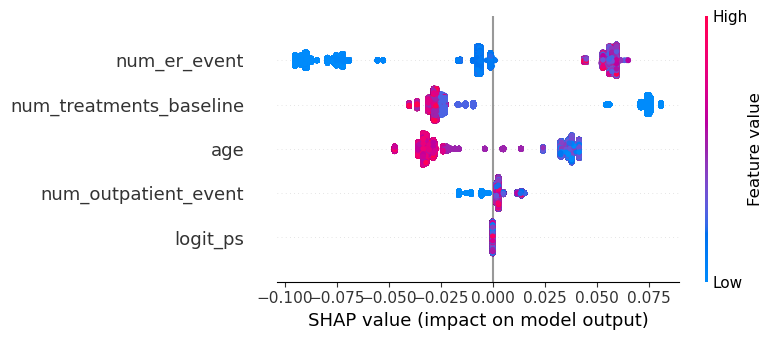

In [17]:
# SHAP values for the tree
import shap
explainer = shap.TreeExplainer(proxy_tree)
shap_values = explainer.shap_values(X_tau_clinical)

# Visualize the SHAP values
shap.summary_plot(shap_values, X_tau_clinical, feature_names=feature_names_clinical, max_display=5)


Building ITE-RD posterior arrays …
  ite_rd shape        : (8000, 114008)
  rd_treated shape    : (8000, 23059)
  mean(CATT)          : -0.04716

── A: GATES plot ──


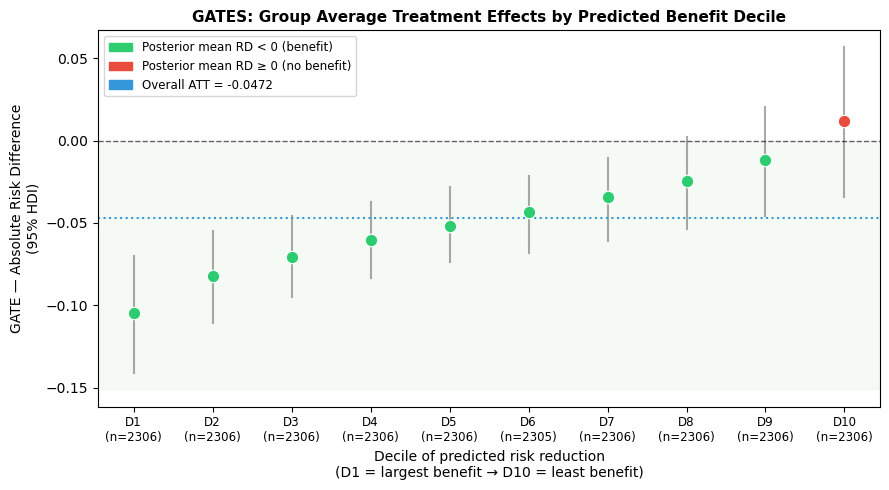

 decile    n  gate_mean        lo        hi  p_benefit
      1 2306  -0.104587 -0.141141 -0.070260   1.000000
      2 2306  -0.082474 -0.110857 -0.055154   1.000000
      3 2306  -0.070401 -0.094691 -0.045512   1.000000
      4 2306  -0.060543 -0.083220 -0.037555   1.000000
      5 2306  -0.051726 -0.073440 -0.028297   1.000000
      6 2305  -0.043191 -0.068097 -0.021260   0.999250
      7 2306  -0.034490 -0.060642 -0.010435   0.994875
      8 2306  -0.024445 -0.053467  0.002070   0.960125
      9 2306  -0.011777 -0.045957  0.020250   0.750250
     10 2306   0.012004 -0.033972  0.056554   0.324125


In [18]:
# ── Step 0: (Re)build ITE-RD posterior ───────────────────────────────
print("Building ITE-RD posterior arrays …")
ite_rd, rd_treated, mean_rd_treated, treated_mask = build_ite_rd_inplace(
    trace_bcf, X_mu, X_tau, T, constant_intercept, mu_term="mu_residual")
print(f"  ite_rd shape        : {ite_rd.shape}")
print(f"  rd_treated shape    : {rd_treated.shape}")
print(f"  mean(CATT)          : {rd_treated.mean():.5f}")

# ── A: GATES ─────────────────────────────────────────────────────────
print("\n── A: GATES plot ──")
gates_df = plot_gates(
    rd_treated, mean_rd_treated,
    n_deciles=10,
    save_path="fig_gates_rd.png"
)
print(gates_df.to_string(index=False))


In [19]:
# ── B: CLAN ──────────────────────────────────────────────────────────
print("\n── B: CLAN table ──")
clan_df = build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.10
)
print_clan_table(clan_df, top_pct=0.10)


── B: CLAN table ──

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 10% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=2306) Rest of treated (n=20753)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Unique Treatments - Baseline         continuous   2.26 ± 0.96                1.37 ± 1.15                                0.89                 0.84
ER Visits                            continuous   2.19 ± 3.12                8.17 ± 9.84                                5.98                 0.82
Logit Propensity Score               continuo

In [20]:
clan_df = build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.90
)
print_clan_table(clan_df, top_pct=0.90)


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 90% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=2306) Rest of treated (n=20753)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Unique Treatments - Baseline         continuous   0.83 ± 0.97                1.53 ± 1.16                                0.70                 0.65
Logit Propensity Score               continuous   -0.26 ± 0.98               -0.72 ± 1.10                               0.46                 0.44
ER Visits                            continuous   11.47 ± 11.45   

In [21]:
# build clan table for each decile of GATES
for decile in range(1, 11):
    print(f"\n── CLAN table for GATES Decile {decile} ──")
    clan_df_decile = build_clan_table(
        mean_rd_treated, X, T,
        top_pct=decile/10,
        smd_threshold=0.10,
    )
    print_clan_table(clan_df_decile, top_pct=decile/10)


── CLAN table for GATES Decile 1 ──

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 10% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=2306) Rest of treated (n=20753)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Unique Treatments - Baseline         continuous   2.26 ± 0.96                1.37 ± 1.15                                0.89                 0.84
ER Visits                            continuous   2.19 ± 3.12                8.17 ± 9.84                                5.98                 0.82
Logit Propensity Score       

In [22]:
X.columns

Index(['age', 'gold_class', 'moderate_exac_count', 't2dm_present',
       'num_treatments_baseline', 'num_outpatient_event', 'num_er_event',
       'Acute_IHD_flag', 'CAD_flag', 'PVD_flag', 'atopic_disease_flag',
       'ckd_flag', 'dyslipidemia_flag', 'haemorrhagic_stroke_flag',
       'heart_failure_flag', 'hypertension_flag', 'ischemic_stroke_flag',
       'obstructive_sleep_apnea_flag', 'smokers_flag',
       'days_since_last_moderate_exac', 'Antibiotics_flag', 'ICS_LABA_flag',
       'ICS_LABA_LAMA_flag', 'LABA_LAMA_flag', 'LAMA_flag', 'OCS_flag',
       'SABA_flag', 'bmi_20_25', 'bmi_above_25', 'bmi_present',
       'hba1c_missing', 'sex_Female', 'region_Midwest', 'region_Northeast',
       'region_South', 'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

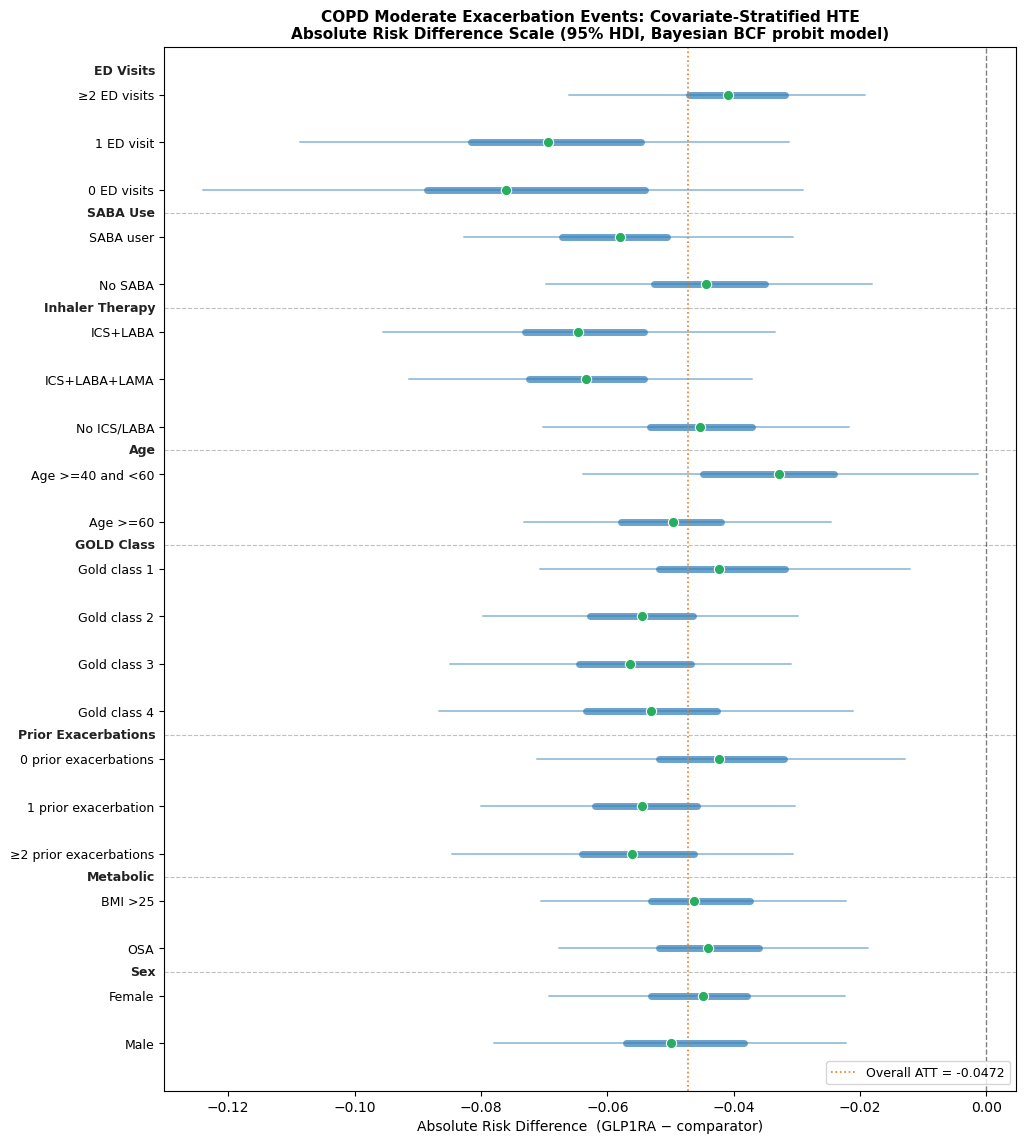

              group                  label     n      mean      lo95      hi95  p_benefit
          ED Visits           ≥2 ED visits 18554 -0.040979 -0.066067 -0.019281   0.999125
          ED Visits             1 ED visit  2291 -0.069318 -0.108649 -0.031229   0.999750
          ED Visits            0 ED visits  2214 -0.076059 -0.124039 -0.029059   0.999625
           SABA Use              SABA user  4707 -0.057974 -0.082707 -0.030559   0.999875
           SABA Use                No SABA 18352 -0.044390 -0.069750 -0.018083   0.999125
    Inhaler Therapy               ICS+LABA  2090 -0.064695 -0.095540 -0.033413   1.000000
    Inhaler Therapy          ICS+LABA+LAMA  3535 -0.063313 -0.091427 -0.037171   1.000000
    Inhaler Therapy            No ICS/LABA 20969 -0.045416 -0.070144 -0.021744   0.999500
                Age       Age >=40 and <60  3390 -0.032886 -0.063776 -0.001383   0.977750
                Age               Age >=60 19669 -0.049624 -0.073227 -0.024650   1.000000
         G

In [23]:
# ══════════════════════════════════════════════════════════════════════════
# CELL C — HTE Forest Plot on the absolute Risk Difference scale
# Assumes: ite_rd, X, T, constant_intercept are in scope from Cell A
# ══════════════════════════════════════════════════════════════════════════

def rd_stratum(ite_rd, full_mask, T_arr, hdi_prob=0.95):
    """CATE among treated patients within full_mask."""
    mask = full_mask & T_arr.astype(bool)
    if mask.sum() < 20:
        return None
    draws      = ite_rd[:, mask].mean(axis=1)
    hdi_v      = az.hdi(draws, hdi_prob=hdi_prob)
    lo50, hi50 = az.hdi(draws, hdi_prob=0.50)
    return dict(mean=draws.mean(), lo95=hdi_v[0], hi95=hdi_v[1],
                lo50=lo50, hi50=hi50,
                p_benefit=float((draws < 0).mean()), n=int(mask.sum()))

Xd = X.reset_index(drop=True)

strata = [
    ("≥2 ED visits",          "ED Visits",          (Xd["num_er_event"] >= 2).values),
    ("1 ED visit",            "ED Visits",          (Xd["num_er_event"] == 1).values),
    ("0 ED visits",           "ED Visits",          (Xd["num_er_event"] == 0).values),
    ("SABA user",             "SABA Use",           (Xd["SABA_flag"] == 1).values),
    ("No SABA",               "SABA Use",           (Xd["SABA_flag"] == 0).values),
    ("ICS+LABA",              "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 1).values),
    ("ICS+LABA+LAMA",         "Inhaler Therapy",    ((Xd["ICS_LABA_LAMA_flag"]==1)).values),
    ("No ICS/LABA",           "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 0).values),
    ("Age >=18 and <40",       "Age",               ((Xd["age"] >= 18) & (Xd["age"] < 40)).values),
    ("Age >=40 and <60",       "Age",               ((Xd["age"] >= 40) & (Xd["age"] < 60)).values),
    ("Age >=60",               "Age",               (Xd["age"] >= 60).values),
    ("Gold class 1",           "GOLD Class",        (Xd["gold_class"] == 1).values),
    ("Gold class 2",         "GOLD Class",          (Xd["gold_class"] == 2).values),
    ("Gold class 3",         "GOLD Class",          (Xd["gold_class"] == 3).values),
    ("Gold class 4",           "GOLD Class",        (Xd["gold_class"] == 4).values),
    ("0 prior exacerbations", "Prior Exacerbations",(Xd["moderate_exac_count"] == 0).values),
    ("1 prior exacerbation",  "Prior Exacerbations",(Xd["moderate_exac_count"] == 1).values),
    ("≥2 prior exacerbations","Prior Exacerbations",(Xd["moderate_exac_count"] >= 2).values),
    ("BMI >25",               "Metabolic",          (Xd["bmi_above_25"] == 1).values),
    ("OSA",                   "Metabolic",          (Xd["obstructive_sleep_apnea_flag"]==1).values),
    ("Female",                "Sex",                (Xd["sex_Female"] == 1).values),
    ("Male",                  "Sex",                (Xd["sex_Female"] == 0).values),
]

rows = []
for label, group, mask in strata:
    r = rd_stratum(ite_rd, mask, T)
    if r:
        rows.append({"label": label, "group": group, **r})

forest_df = pd.DataFrame(rows)

# ── Draw ──────────────────────────────────────────────────────────────────
n_r    = len(forest_df)
colour = "#2c7bb6"
fig, ax = plt.subplots(figsize=(11, max(6, 0.55 * n_r + 2)))

y_pos          = np.arange(n_r)[::-1]
current_group  = None

for i, (_, row) in enumerate(forest_df.iterrows()):
    y = y_pos[i]
    if row["group"] != current_group:
        current_group = row["group"]
        # add line break and group label
        if i > 0:
            ax.axhline(y + 0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax.text(-0.01, y + 0.5, row["group"],
                transform=ax.get_yaxis_transform(),
                ha="right", va="center",
                fontsize=9, fontweight="bold", color="#222222")
        # add more space above and below group label

    ax.plot([row["lo95"], row["hi95"]], [y, y],
            color=colour, lw=1.4, alpha=0.45, solid_capstyle="round")
    ax.plot([row["lo50"], row["hi50"]], [y, y],
            color=colour, lw=5,   alpha=0.70, solid_capstyle="round")
    dot_c = "#27ae60" if row["mean"] < 0 else "#e74c3c"
    ax.scatter(row["mean"], y, s=55, color=dot_c, zorder=5,
               edgecolors="white", linewidths=0.8)
    # ax.text(forest_df["hi95"].max() + 0.001, y,
    #         f"  {row['mean']:+.4f} [{row['lo95']:+.4f}, {row['hi95']:+.4f}]  "
    #         f"P(benefit)={row['p_benefit']:.2f}  n={row['n']}",
    #         va="center", fontsize=7.5, color="gray")

att_mean = ite_rd[:, T.astype(bool)].mean()
ax.axvline(0,        color="black",   lw=1,   ls="--", alpha=0.5)
ax.axvline(att_mean, color="#e67e22", lw=1.2, ls=":",
           label=f"Overall ATT = {att_mean:.4f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"].tolist(), fontsize=9)
ax.set_xlabel(
    "Absolute Risk Difference  (GLP1RA − comparator)",
    fontsize=10)
ax.set_title(
    "COPD Moderate Exacerbation Events: Covariate-Stratified HTE\n"
    "Absolute Risk Difference Scale (95% HDI, Bayesian BCF probit model)",
    fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
#fig.tight_layout()
plt.show()
print(forest_df[["group","label","n","mean","lo95","hi95","p_benefit"]].to_string(index=False))

In [24]:
att_draws = ite_rd[:, treated_mask].mean(axis=1)
att_mean  = att_draws.mean()
ax.axvline(att_mean, color="#e67e22", lw=1.2, linestyle=":",
            label=f"Overall ATT = {att_mean:.4f}")
att_hdi = az.hdi(att_draws, hdi_prob=0.95)
print(f"Overall ATT = {att_mean:.4f} \n      95% HDI: {att_hdi[0]:.4f} to {att_hdi[1]:.4f}")


Overall ATT = -0.0472 
      95% HDI: -0.0719 to -0.0243
